# 관악 하천역류 가설 검증 — 도림천 수위 × 조원로 침수

사용자 정보: 관악 침수는 하수 만관이 아니라 **하천역류·땅꺼짐 저지대 침수**.
한강홍수통제소 hrfco에서 **관악 도림천 수위계 2개소(신림5교·신대방1교)** 전 기간(2024-06~2025-09) 확보.
검증: **조원로 5-6 도로침수 시각에 도림천 수위가 높은가?** (하천역류면 침수=하천 고수위 동반)

In [1]:
import os; os.chdir('/home/namjun/city_flood')
import sys; sys.path.insert(0,'scripts'); from krfont import set_korean; set_korean()
import pandas as pd, numpy as np, matplotlib.pyplot as plt
EB="dataset/processed/eda_based/"
riv=pd.read_parquet("data/river_level_10min.parquet")
sl=riv[riv.obsnm=='신림5교'].set_index('ts').wl.sort_index()
p95,p99=sl.quantile(.95),sl.quantile(.99)
print(f"도림천 신림5교 wl: 중앙 {sl.median():.2f} p95 {p95:.2f} p99 {p99:.2f} 최대 {sl.max():.2f}m (강우반응폭 {sl.max()-sl.median():.2f}m)")
rp=pd.read_parquet(EB+"road_panel_10min.parquet",columns=['sensor_id','ts10','flood_t6'])
fl=rp[(rp.sensor_id=='조원로 5-6')&(rp.flood_t6==1)].ts10
fl=fl[(fl>=riv.ts.min())&(fl<=riv.ts.max())].sort_values()

도림천 신림5교 wl: 중앙 2.39 p95 2.59 p99 2.79 최대 3.58m (강우반응폭 1.19m)


## 1. 침수시 도림천 수위 (순간 + ±6h 창)

In [2]:
wl_inst=sl.reindex(fl,method='nearest')
win=[sl[(sl.index>=t-pd.Timedelta('6h'))&(sl.index<=t+pd.Timedelta('6h'))].max() for t in fl]
win=np.array(win)
print(f"조원로 침수 {len(fl)}회")
print(f"  순간 도림천wl: 중앙 {wl_inst.median():.2f}(전체 {sl.median():.2f}) | >p95 {(wl_inst>p95).mean():.0%} | >p99 {(wl_inst>p99).mean():.0%}")
print(f"  ±6h 최대wl  : 중앙 {np.median(win):.2f} | >p95 {(win>p95).mean():.0%} | >p99 {(win>p99).mean():.0%}")
print(f"\n→ 침수의 90%가 도림천 평상시 수위 = 하천역류 동반 아님")
print("월분포 — 조원로침수:",fl.dt.month.value_counts().sort_index().to_dict())
print("월분포 — 도림천>p99:",sl[sl>p99].index.month.value_counts().sort_index().to_dict())
print("→ 둘 다 여름(9월)에 몰리나 = 같은 폭우철일 뿐, 사건단위 동조 아님")

조원로 침수 30회
  순간 도림천wl: 중앙 2.46(전체 2.39) | >p95 7% | >p99 3%
  ±6h 최대wl  : 중앙 2.46 | >p95 10% | >p99 7%

→ 침수의 90%가 도림천 평상시 수위 = 하천역류 동반 아님
월분포 — 조원로침수: {3: 1, 4: 1, 6: 3, 7: 4, 8: 1, 9: 16, 11: 2, 12: 2}
월분포 — 도림천>p99: {5: 5, 6: 7, 7: 353, 8: 49, 9: 248, 10: 1}
→ 둘 다 여름(9월)에 몰리나 = 같은 폭우철일 뿐, 사건단위 동조 아님


## 2. 시각화 — 2025년 9월(침수 최다월) 도림천 수위 vs 조원로 침수 시점

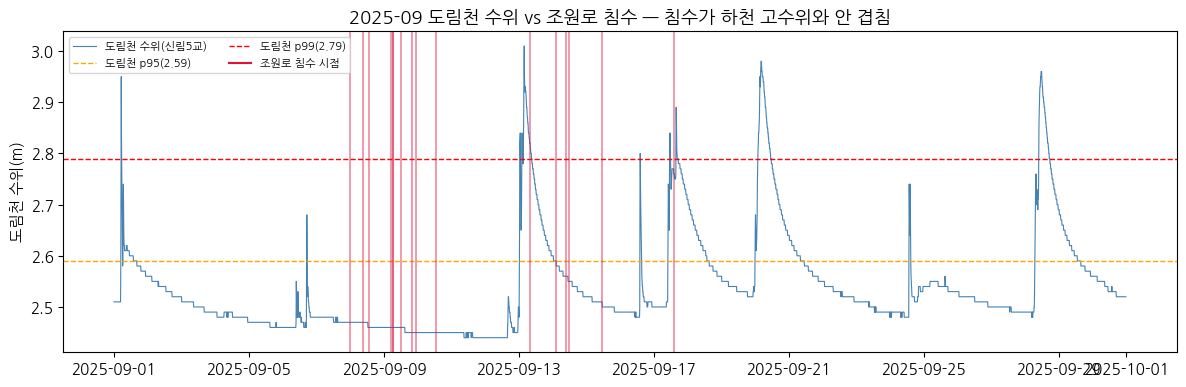

saved


In [3]:
seg=sl['2025-09-01':'2025-09-30']
flS=fl[(fl>=pd.Timestamp('2025-09-01'))&(fl<=pd.Timestamp('2025-09-30'))]
fig,ax=plt.subplots(figsize=(12,4))
ax.plot(seg.index,seg.values,c='steelblue',lw=0.8,label='도림천 수위(신림5교)')
ax.axhline(p95,ls='--',c='orange',lw=1,label=f'도림천 p95({p95:.2f})')
ax.axhline(p99,ls='--',c='red',lw=1,label=f'도림천 p99({p99:.2f})')
for t in flS: ax.axvline(t,c='crimson',alpha=0.5,lw=1.2)
ax.plot([],[],c='crimson',label='조원로 침수 시점')
ax.set_ylabel('도림천 수위(m)'); ax.set_title('2025-09 도림천 수위 vs 조원로 침수 — 침수가 하천 고수위와 안 겹침')
ax.legend(fontsize=8,ncol=2); plt.tight_layout()
os.makedirs('reports/figures_sewer',exist_ok=True)
plt.savefig('reports/figures_sewer/09_river_backwater.png',dpi=110,bbox_inches='tight'); plt.show(); print('saved')

## 결론
- **하천역류(도림천)는 조원로 침수의 원인이 아니다**: 침수의 90%(±6h로도)가 도림천 평상시 수위, p95 초과는 7~10%뿐.
- 도림천은 폭우에 반응함(반응폭 1.2m, 고수위 7~9월 집중)이나 **조원로 침수와 사건단위로 동조 안 함**. 9월 동시 다발은 '같은 폭우철'일 뿐.
- **소거법 결론**: 관악 침수 ≠ 하수 만관, ≠ 도림천 하천역류 → **국지 호우 표면류(pluvial)** 또는 일부 센서 아티팩트(겨울 6건 의심). → **국지 강우강도(레이더)로 확인 필요.**
- ⚠️ 땅꺼짐은 수문 데이터 범위 밖(별도).